# **Introduction**

**Research Background**: This is truly an age of extraordinary technological advancements. Throughout the world, people across different countries, nations, and societies all have, to a certain degree, access to a vast digital world created by the internet. Indeed, the rise of the internet era has completely revolutionized how people think, live, and interact with those around them. Moreover, these developments have also created new opportunities for global communication, employment, education, and entertainment. However, amidst these transformations, concerns also arose in recent years regarding the association between technological use, lifestyle behaviors, and mental health. Hence, the purpose of this research will be to examine the potential relationships among these variables through a systematic process involving data visualization, statistical analysis, and predictive model development.


**Dataset Overview**

Each row represents a unique participant and includes:

Demographics (age, gender, occupation, student/working)

Daily Screen Time (mobile, laptop, TV, total)

Sleep Quality (self-reported rating)

Stress Levels (scale 1–10)

Productivity Score (self-perception)

Mental Wellness Indicators (mood, energy, focus)

# **Research Questions & Hypothesis**

**Research Questions**


1. How is screen time alone associated with measures of mental well-being?
2. How is screen time associated with sleep duration and self-reported sleep quality?
3. Which type of technological behaviors are most strongly associated with mental well-being?
4. To what extent can mental well-being be predicted from technological behaviors along with other indicators?

**Hypothesis**



1.   Screen time will have a strong negative association with mental well-being, sleep duration, and self-reported sleep quality.
2.   Work screen time will have a stronger association with mental wellness compared to leisure screen time.





# **Data Setups**

In [5]:
# Importing modules necessary for data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/ScreenTime vs MentalWellness.csv')
df.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


In [6]:
# General informations about this dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    object 
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    object 
 3   occupation                   400 non-null    object 
 4   work_mode                    400 non-null    object 
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_100           400 non-null    float64
 12  exercise_minutes_per_week    400 non-null    int64  
 13  social_hours_per_wee

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,0.0
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750,NaN
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793,NaN
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000,NaN
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000,NaN
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000,NaN
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000,NaN
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000,NaN


# **Data Cleaning**

In [7]:
# Dropping the unnamed column
df = df.dropna(axis=1)

In [8]:
# Checking for missing values
df.isnull().sum()

,0
user_id,0
age,0
gender,0
occupation,0
work_mode,0
screen_time_hours,0
work_screen_hours,0
leisure_screen_hours,0
sleep_hours,0
sleep_quality_1_5,0


In [9]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [20]:
# Verify that total screen time equals work screen time plus leisure screen time
df['screen_time_validation'] = np.isclose(df['work_screen_hours']+ df['leisure_screen_hours'], df['screen_time_hours'])
df['screen_time_validation'].describe()

,screen_time_validation
count,400
unique,1
top,True
freq,400


In [21]:
# Drop column after verification
df = df.drop(columns='screen_time_validation')

# **Exploratory Data Analysis**

### **Distribution of Numerical Data**

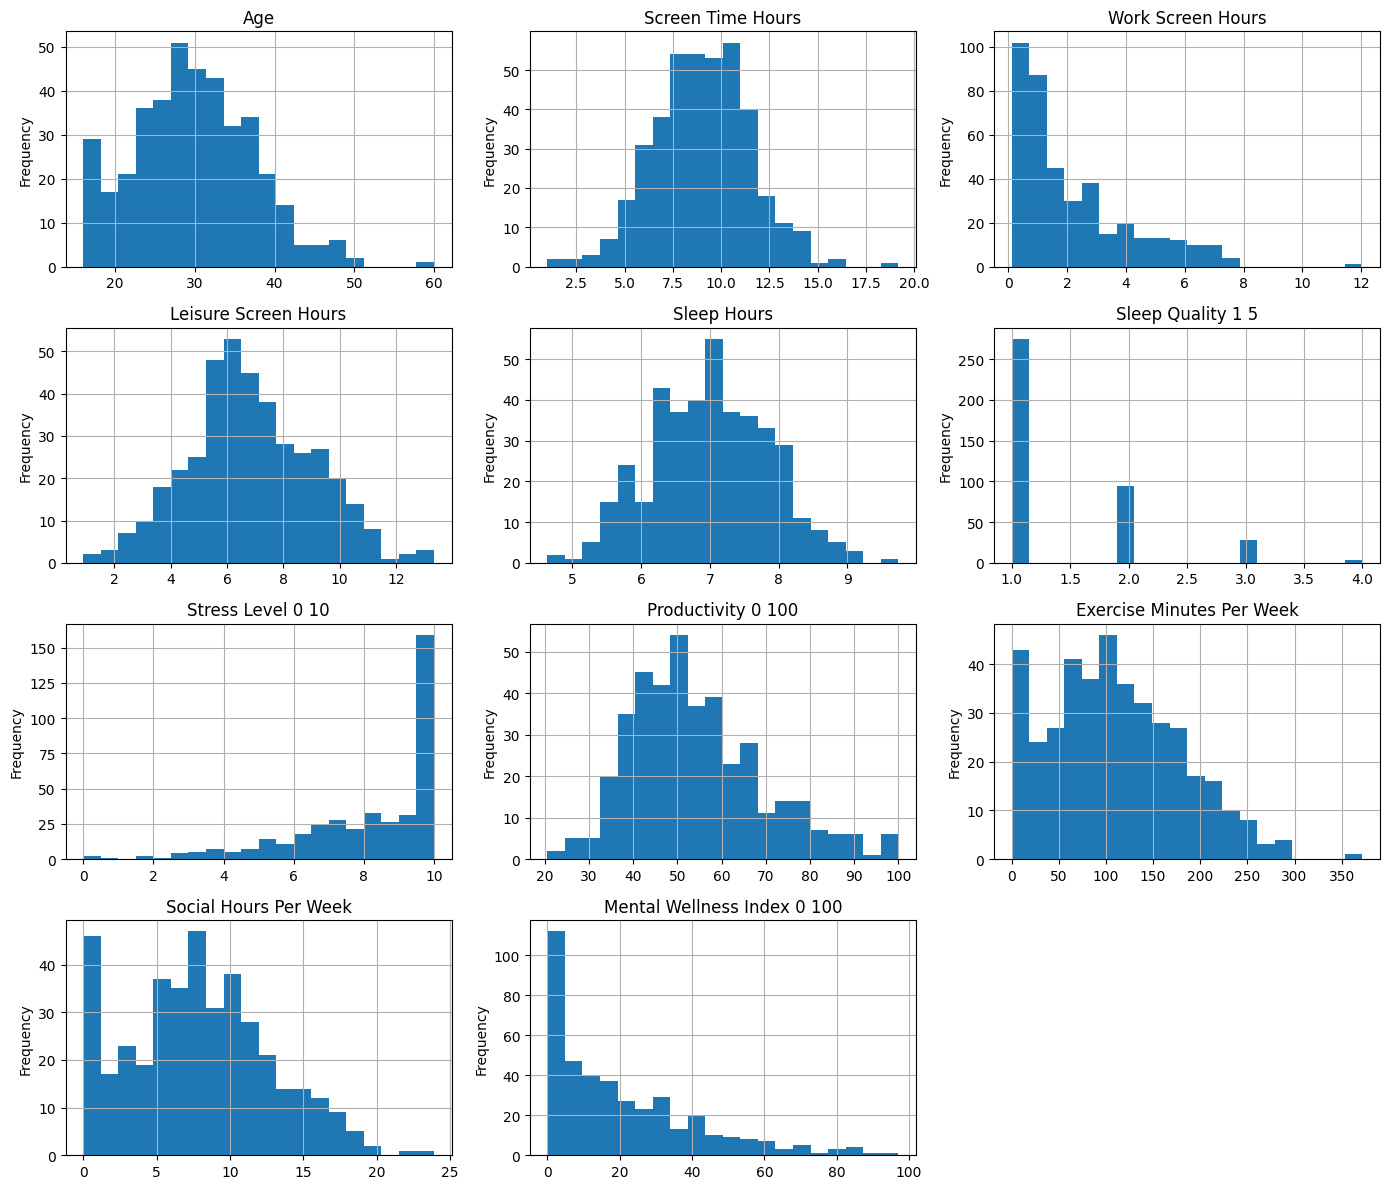

In [34]:
# Examine the overall distributions of numerical variables
plots = df.hist(figsize=(14, 12), bins=20)

for subplot in plots.flatten():
    new_title = subplot.get_title().replace("_", " ").title()
    subplot.set_title(new_title)
    subplot.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### **Distribution of Gender, Occupation, and Work Mode**

,count
gender,
Female,222
Male,170
Non-binary/Other,8


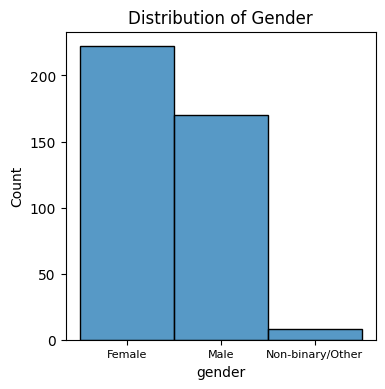

,count
occupation,
Employed,207
Student,107
Self-employed,45
Unemployed,27
Retired,14


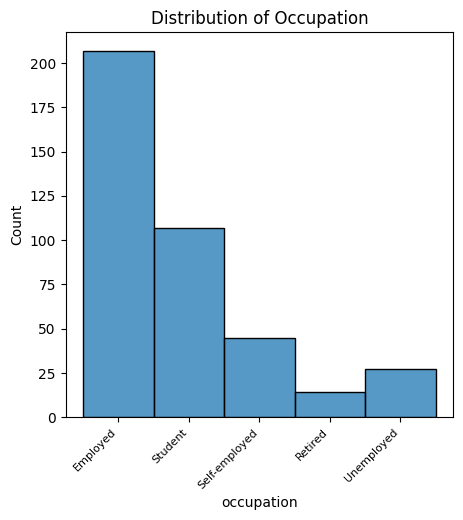

,count
work_mode,
Remote,150
Hybrid,146
In-person,104


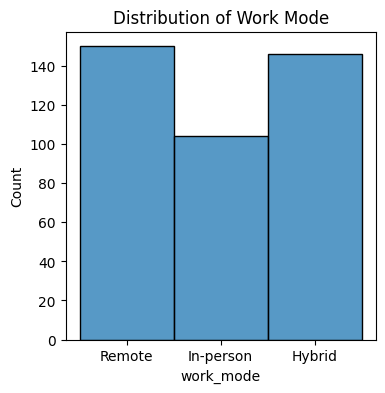

In [ ]:
# Checking for distribution of gender, occupation, and work mode
display(df.gender.value_counts())
plt.figure(figsize=(4,4))
sns.histplot(data = df.gender)
plt.xticks(fontsize=8)
plt.title('Distribution of Gender')
plt.show()


display(df.occupation.value_counts())
plt.figure(figsize=(5,5))
sns.histplot(data = df.occupation)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Distribution of Occupation')
plt.show()


display(df['work_mode'].value_counts())
plt.figure(figsize=(4,4))
sns.histplot(data= df['work_mode'])
plt.title('Distribution of Work Mode')
plt.show()

In [ ]:
# Statistical information on the main indicators
df[[
    'screen_time_hours',
    'sleep_hours',
    'sleep_quality_1_5',
    'stress_level_0_10',
    'mental_wellness_index_0_100'
    ]].describe()


,screen_time_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,mental_wellness_index_0_100
count,400.000000,400.000000,400.000000,400.000000,400.000000
mean,9.024900,7.013175,1.397500,8.150500,20.326750
std,2.491058,0.852421,0.652348,2.094844,20.376793
min,1.000000,4.640000,1.000000,0.000000,0.000000
25%,7.372500,6.397500,1.000000,6.900000,3.675000
50%,9.090000,7.030000,1.000000,8.800000,14.800000
75%,10.495000,7.640000,2.000000,10.000000,30.650000
max,19.170000,9.740000,4.000000,10.000000,97.000000


### **Potential Correlation of Mental Wellness with Gender, Occupation, and Work Mode**

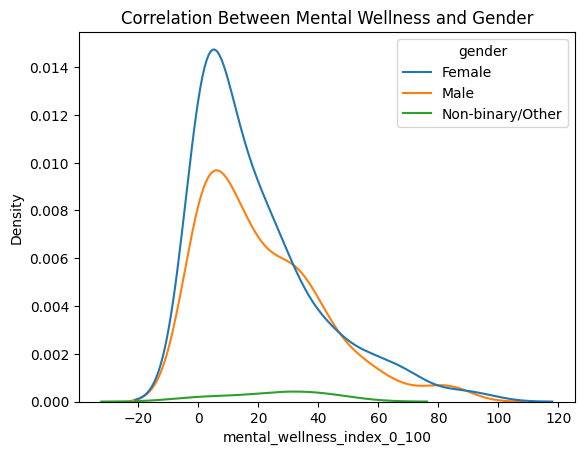

In [ ]:
# Checking for potential correlation between mental wellness and different genders
sns.kdeplot(data= df, x= 'mental_wellness_index_0_100', hue= df['gender'])
plt.title('Correlation Between Mental Wellness and Gender')
plt.show()

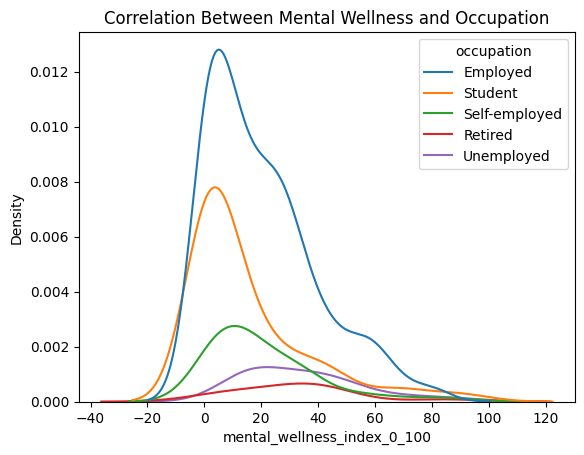

In [ ]:
# Checking for potential correlation between mental wellness and different occupations
sns.kdeplot(data= df, x= 'mental_wellness_index_0_100', hue= df['occupation'])
plt.title('Correlation Between Mental Wellness and Occupation')
plt.show()

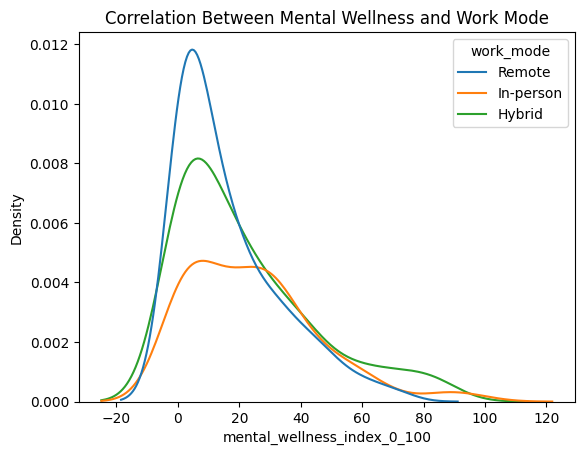

In [ ]:
# Checking for potential correlation between mental wellness and different work modes
sns.kdeplot(data= df, x= 'mental_wellness_index_0_100', hue= df['work_mode'])
plt.title('Correlation Between Mental Wellness and Work Mode')
plt.show()

Participants who work in-person tends to have a higher mental wellness in this particular dataset

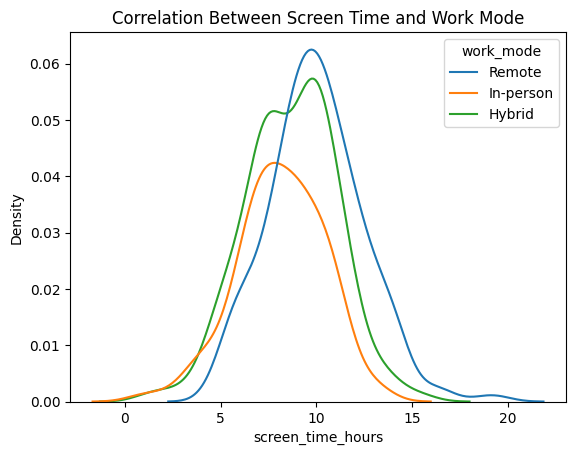

In [ ]:
# The screen time distribution with respect to each work mode
sns.kdeplot(data= df, x= 'screen_time_hours', hue= df['work_mode'])
plt.title('Correlation Between Screen Time and Work Mode')
plt.show()

This might be related to the fact that participants who work in-person also tends to spend lesser time on digital screen.

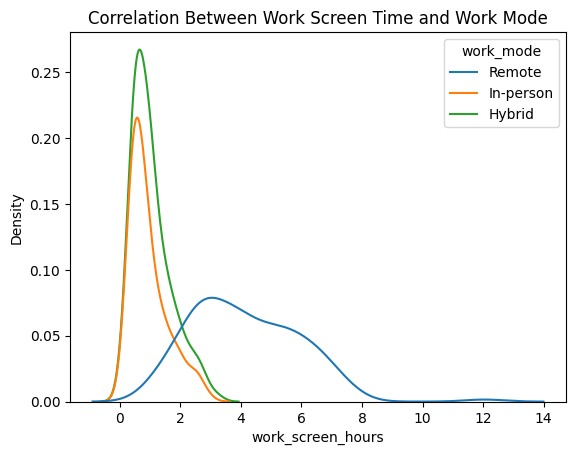

In [ ]:
# The distribution of work screen time  with respect to each work mode
sns.kdeplot(data= df, x= 'work_screen_hours', hue= df['work_mode'])
plt.title('Correlation Between Work Screen Time and Work Mode')
plt.show()

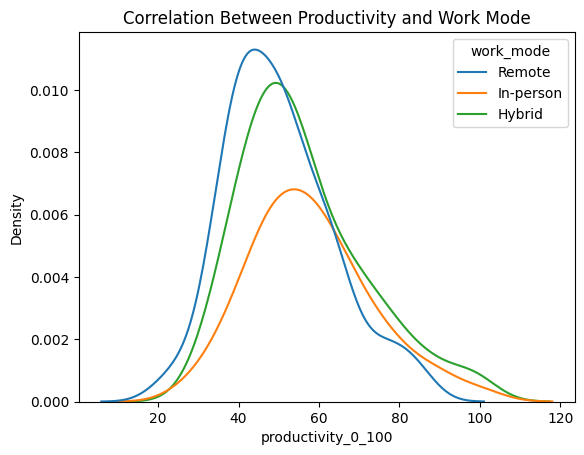

In [ ]:
# The productivity distribution with respect to each work mode
sns.kdeplot(data= df, x= 'productivity_0_100', hue= df['work_mode'])
plt.title('Correlation Between Productivity and Work Mode')
plt.show()

### **How is screen time associated with measures of mental well-being?**

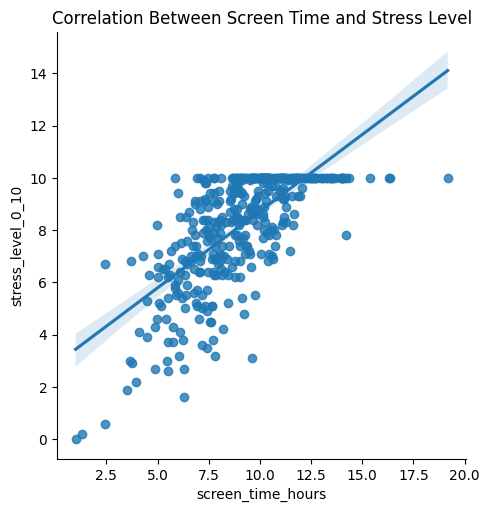

In [ ]:
# Correlation between screen time and mental wellness
sns.lmplot(data=df, x="screen_time_hours", y="stress_level_0_10")
plt.title('Correlation Between Screen Time and Stress Level')
plt.show()

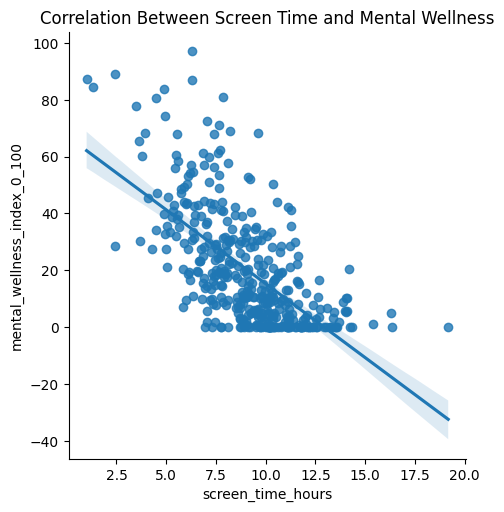

In [ ]:
# Correlation between screen time and mental wellness
sns.lmplot(data=df, x="screen_time_hours", y="mental_wellness_index_0_100")
plt.title('Correlation Between Screen Time and Mental Wellness')
plt.show()

### **How is screen time associated with sleep duration and self-reported sleep quality?**

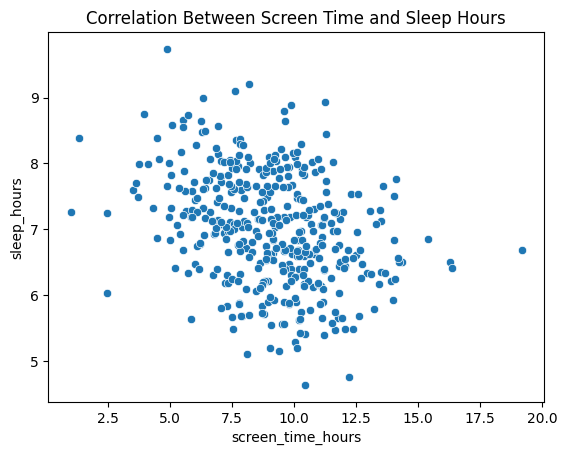

In [ ]:
# Correlation between screen time and sleep hours
sns.scatterplot(data=df, x="screen_time_hours", y="sleep_hours")
plt.title('Correlation Between Screen Time and Sleep Hours')
plt.show()

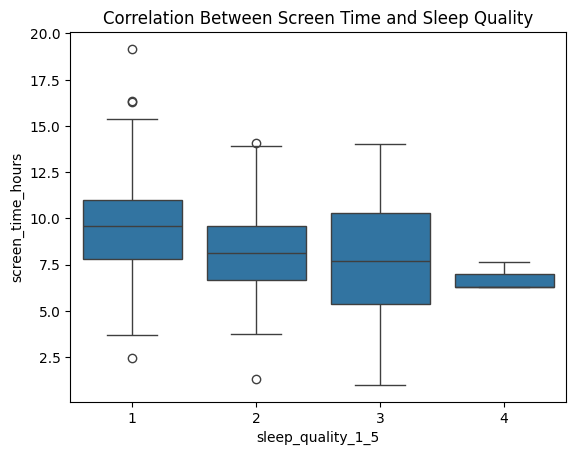

In [ ]:
# Correlation between screen time and sleep quality
sns.boxplot(data=df, x="sleep_quality_1_5", y="screen_time_hours")
plt.title('Correlation Between Screen Time and Sleep Quality')
plt.show()

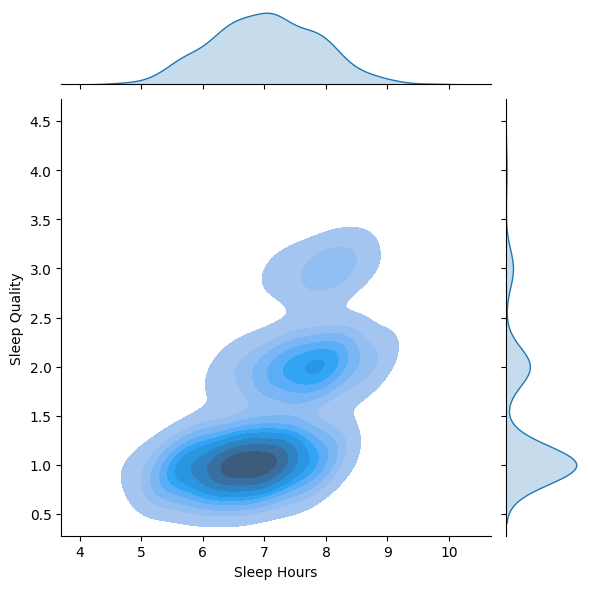

In [ ]:
# Correlation between sleep hours and sleep quality
sns.jointplot(x=df['sleep_hours'], y=df['sleep_quality_1_5'], kind='kde', fill=True)
plt.xlabel('Sleep Hours')
plt.ylabel('Sleep Quality')
plt.show()

Inrease in sleep hours is slightly associated with increase in self-reported sleep quality.

### **Which technological behaviors are most strongly associated with mental well-being?**

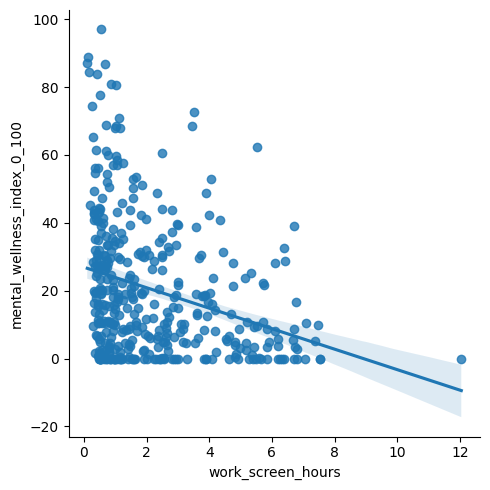

In [35]:
# Correlation between work screen time and mental wellness
sns.lmplot(data=df, x="work_screen_hours", y='mental_wellness_index_0_100')
plt.show()

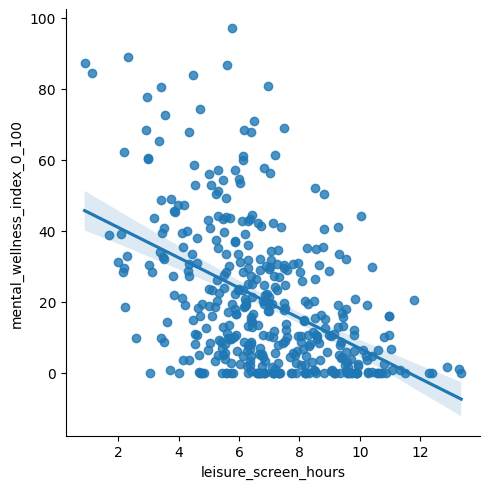

In [ ]:
# Correlation between leisure screen time and mental wellness
sns.lmplot(data=df, x="leisure_screen_hours", y='mental_wellness_index_0_100')
plt.show()

According to the plots above, it must be noted that leisure screen time does seem to possess a stronger correlation with respect to mental wellness when compared to work screen time.

### **Correlation Between Mental Wellness and Lifestyle Variables**

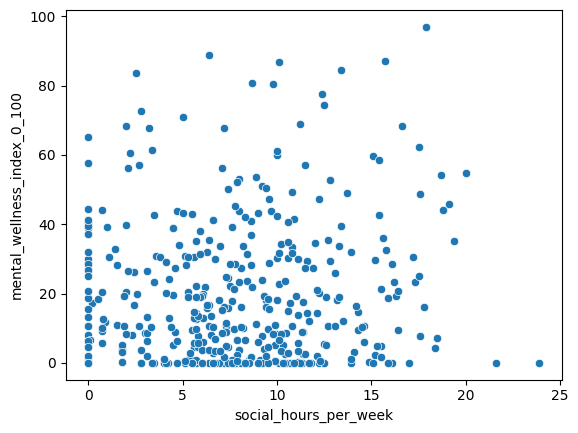

In [ ]:
# Correlation between social hours and mental wellness
sns.scatterplot(data=df, x='social_hours_per_week', y='mental_wellness_index_0_100')
plt.show()

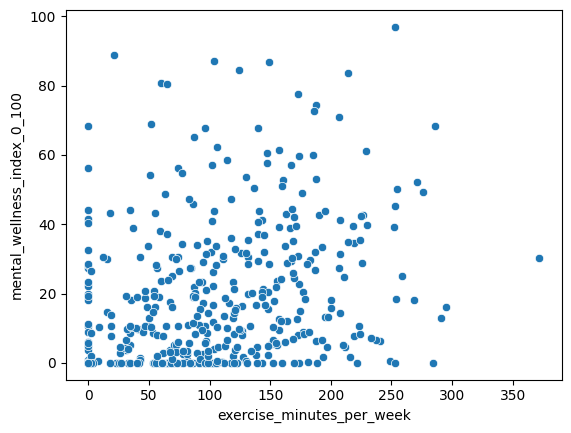

In [ ]:
# Correlation between leisure exercise minutes and mental wellness
sns.scatterplot(data=df, x='exercise_minutes_per_week', y='mental_wellness_index_0_100')
plt.show()

### **Correlation Summary**

,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,exercise_minutes_per_week,social_hours_per_week,productivity_0_100,mental_wellness_index_0_100
screen_time_hours,1.000000,0.519950,0.669490,-0.331314,-0.278365,0.697812,-0.171653,-0.198124,-0.706537,-0.635943
work_screen_hours,0.519950,1.000000,-0.286414,-0.133243,-0.100854,0.307424,-0.078305,-0.051876,-0.335697,-0.286261
leisure_screen_hours,0.669490,-0.286414,1.000000,-0.255747,-0.224523,0.515358,-0.124439,-0.177113,-0.500558,-0.464366
sleep_hours,-0.331314,-0.133243,-0.255747,1.000000,0.614381,-0.481137,0.188538,0.023130,0.517313,0.580824
sleep_quality_1_5,-0.278365,-0.100854,-0.224523,0.614381,1.000000,-0.558870,0.095391,0.017767,0.644802,0.750092
stress_level_0_10,0.697812,0.307424,0.515358,-0.481137,-0.558870,1.000000,-0.159670,-0.114268,-0.879539,-0.913818
exercise_minutes_per_week,-0.171653,-0.078305,-0.124439,0.188538,0.095391,-0.159670,1.000000,0.019231,0.131879,0.228592
social_hours_per_week,-0.198124,-0.051876,-0.177113,0.023130,0.017767,-0.114268,0.019231,1.000000,0.117232,0.070400
productivity_0_100,-0.706537,-0.335697,-0.500558,0.517313,0.644802,-0.879539,0.131879,0.117232,1.000000,0.902249
mental_wellness_index_0_100,-0.635943,-0.286261,-0.464366,0.580824,0.750092,-0.913818,0.228592,0.070400,0.902249,1.000000


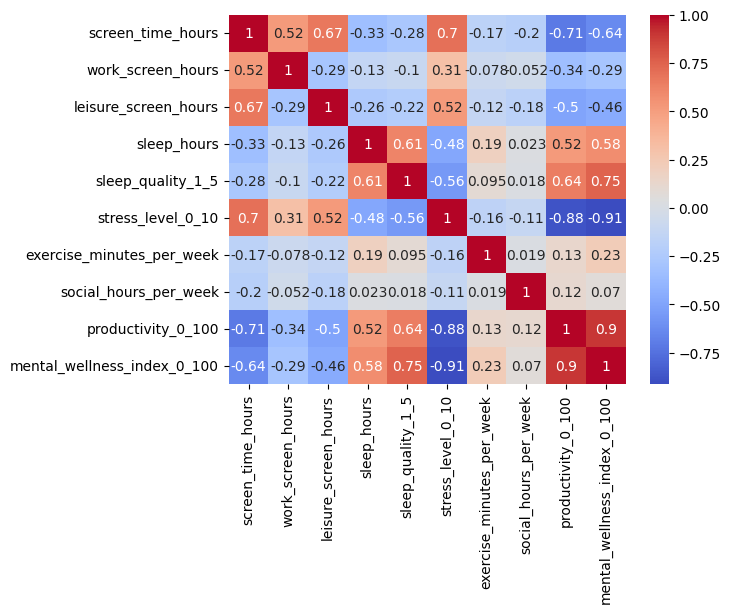

In [ ]:
# Correlation Summary
corr = df[[

    "screen_time_hours",

    "work_screen_hours",

    "leisure_screen_hours",

    "sleep_hours",

    "sleep_quality_1_5",

    "stress_level_0_10",

    "exercise_minutes_per_week",

    "social_hours_per_week",

    "productivity_0_100",

    "mental_wellness_index_0_100"

]].corr()

display(corr)
sns.heatmap(data=corr, annot=True, cmap="coolwarm")
plt.show()

Main mental wellness indicators are: screen time, leisure screen time, sleep hours, sleep quality, stress level, and productivity.

# **Statistical Analysis**

In [38]:
import statsmodels.api as sm

### Simple Linear Regression: Screen Time -> Mental Wellness

In [39]:
# Simple Linear Regression: Screen Time -> Mental Wellness
X = df["screen_time_hours"]
y = df["mental_wellness_index_0_100"]
X = sm.add_constant(X)
model_1 = sm.OLS(y, X).fit()
print(model_1.summary())

                                 OLS Regression Results                                
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.404
Model:                                     OLS   Adj. R-squared:                  0.403
Method:                          Least Squares   F-statistic:                     270.3
Date:                         Mon, 05 Oct 2026   Prob (F-statistic):           1.02e-46
Time:                                 03:01:01   Log-Likelihood:                -1669.2
No. Observations:                          400   AIC:                             3342.
Df Residuals:                              398   BIC:                             3350.
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

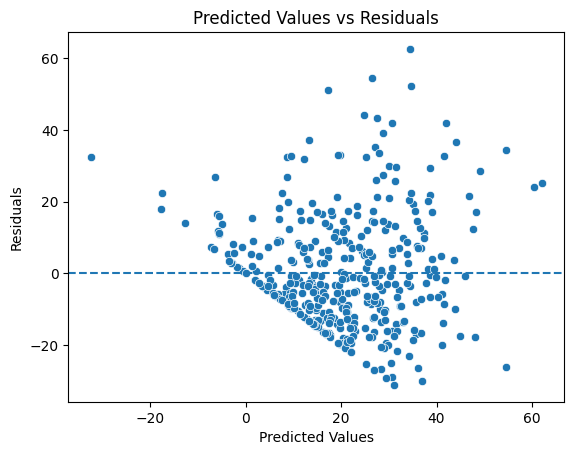

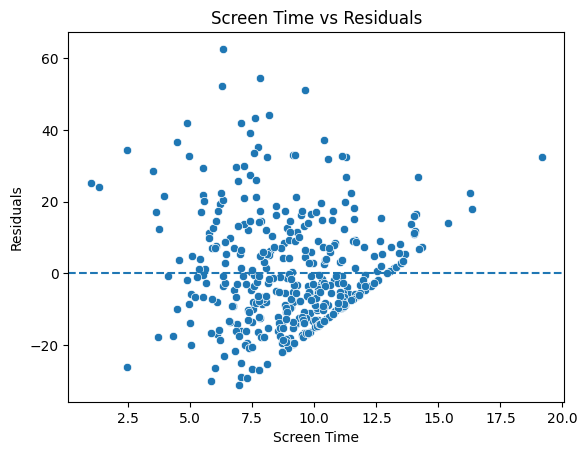

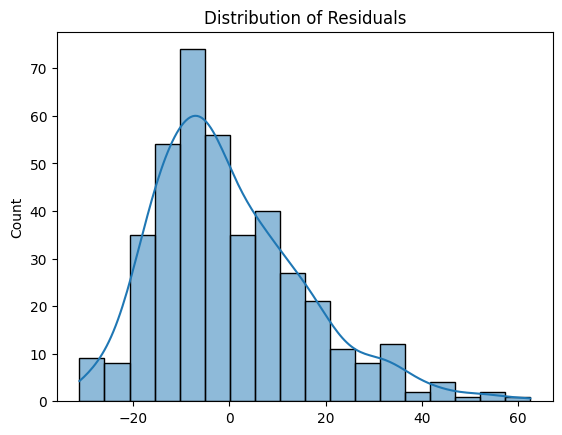

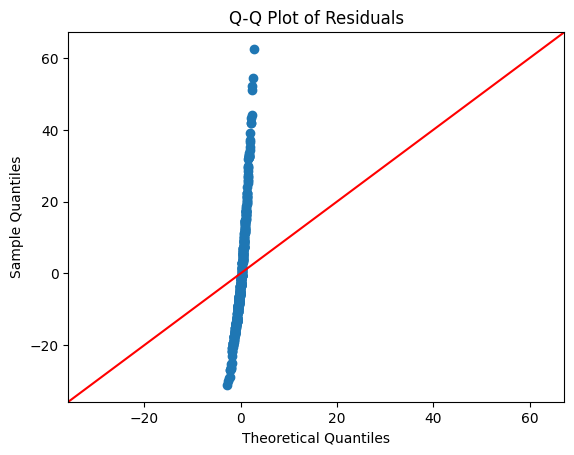

In [40]:
# Model Evaluation

residuals = model_1.resid
predictions = model_1.fittedvalues
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted Values vs Residuals")
plt.show()

sns.scatterplot(x=df['screen_time_hours'], y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Screen Time")
plt.ylabel("Residuals")
plt.title("Screen Time vs Residuals")
plt.show()

sns.histplot(data=residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

## Simple Linear Regression: Screen Time -> Sleep Hours

In [41]:
# Simple Linear Regression: Screen Time -> Sleep Hours
X = df["screen_time_hours"]
y = df["sleep_hours"]
X = sm.add_constant(X)
model_2 = sm.OLS(y, X).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:            sleep_hours   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     49.07
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.06e-11
Time:                        03:01:02   Log-Likelihood:                -479.95
No. Observations:                 400   AIC:                             963.9
Df Residuals:                     398   BIC:                             971.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.0364      0.15

In [42]:
# Simple Linear Regression: Screen Time -> Sleep Quality
X = df["screen_time_hours"]
y = df["sleep_quality_1_5"]
X = sm.add_constant(X)
model_2 = sm.OLS(y, X).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:      sleep_quality_1_5   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     33.43
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.49e-08
Time:                        03:01:02   Log-Likelihood:                -380.07
No. Observations:                 400   AIC:                             764.1
Df Residuals:                     398   BIC:                             772.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.0554      0.11

## Simple Linear Regression: Screen Time -> Productivity

In [43]:
# Simple Linear Regression: Screen Time -> Productivity
X = df["screen_time_hours"]
y = df["productivity_0_100"]
X = sm.add_constant(X)
model_3 = sm.OLS(y, X).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_0_100   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     396.7
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           9.67e-62
Time:                        03:01:02   Log-Likelihood:                -1512.5
No. Observations:                 400   AIC:                             3029.
Df Residuals:                     398   BIC:                             3037.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                92.7537      2.00

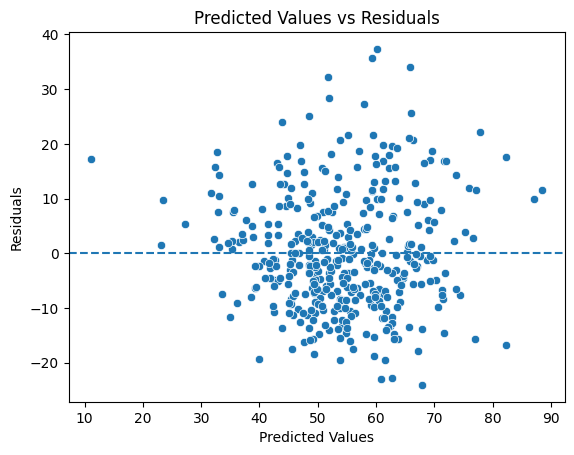

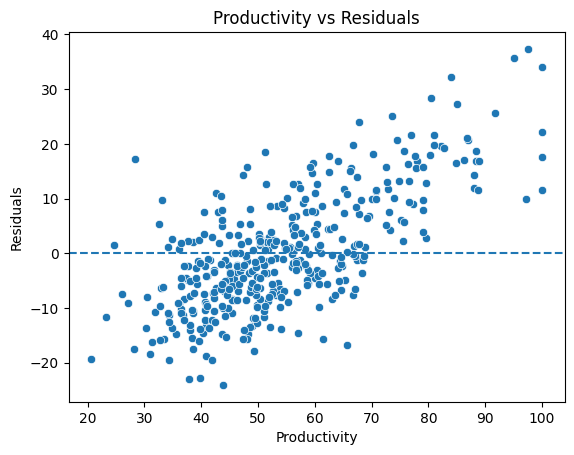

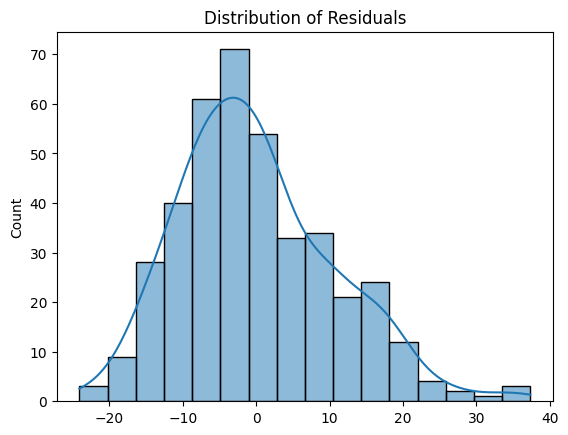

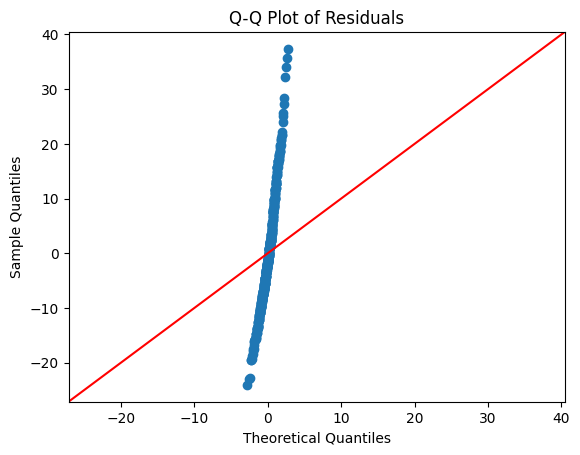

In [44]:
# Model Evaluation

residuals = model_3.resid
predictions = model_3.fittedvalues
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted Values vs Residuals")
plt.show()

sns.scatterplot(x=df['productivity_0_100'], y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Productivity")
plt.ylabel("Residuals")
plt.title("Productivity vs Residuals")
plt.show()

sns.histplot(data=residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

In [45]:
# Simple Linear Regression: Screen Time -> Stress Level
X = df["screen_time_hours"]
y = df["stress_level_0_10"]
X = sm.add_constant(X)
model_4 = sm.OLS(y, X).fit()
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:      stress_level_0_10   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     377.7
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.20e-59
Time:                        03:01:03   Log-Likelihood:                -729.39
No. Observations:                 400   AIC:                             1463.
Df Residuals:                     398   BIC:                             1471.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.8545      0.28

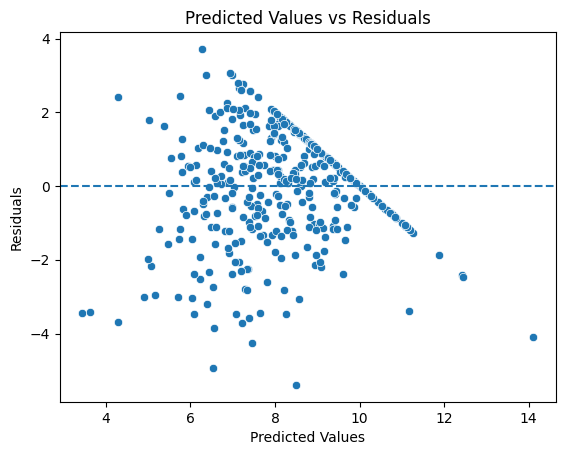

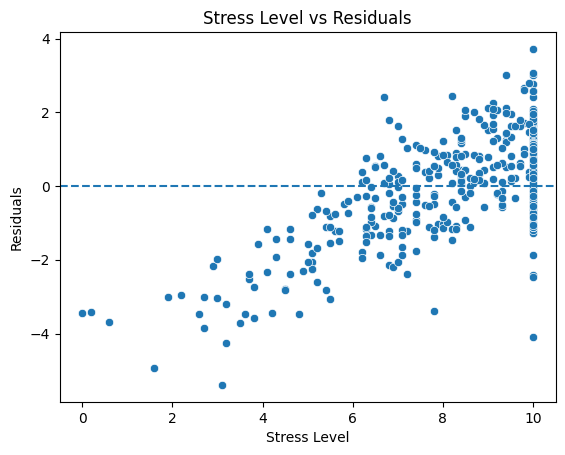

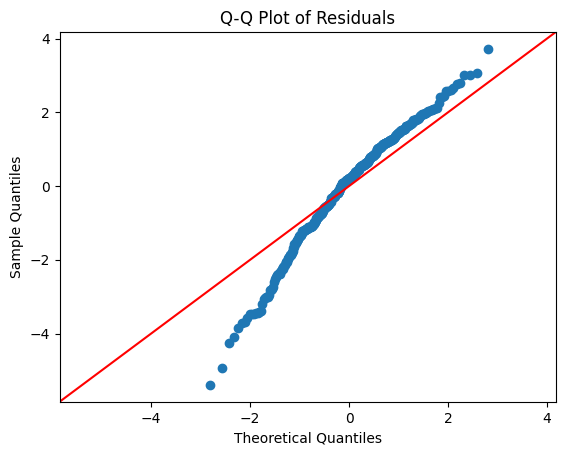

In [46]:
# Model Evaluation

residuals = model_4.resid
predictions = model_4.fittedvalues
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted Values vs Residuals")
plt.show()

sns.scatterplot(x=df["stress_level_0_10"], y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Stress Level")
plt.ylabel("Residuals")
plt.title("Stress Level vs Residuals")
plt.show()

sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

In [47]:
# Simple Linear Regression: Sleep Hours -> Mental Wellness
X = df["sleep_hours"]
y = df["mental_wellness_index_0_100"]
X = sm.add_constant(X)
model_5 = sm.OLS(y, X).fit()
print(model_5.summary())

                                 OLS Regression Results                                
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.337
Model:                                     OLS   Adj. R-squared:                  0.336
Method:                          Least Squares   F-statistic:                     202.6
Date:                         Mon, 05 Oct 2026   Prob (F-statistic):           1.86e-37
Time:                                 03:01:03   Log-Likelihood:                -1690.5
No. Observations:                          400   AIC:                             3385.
Df Residuals:                              398   BIC:                             3393.
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

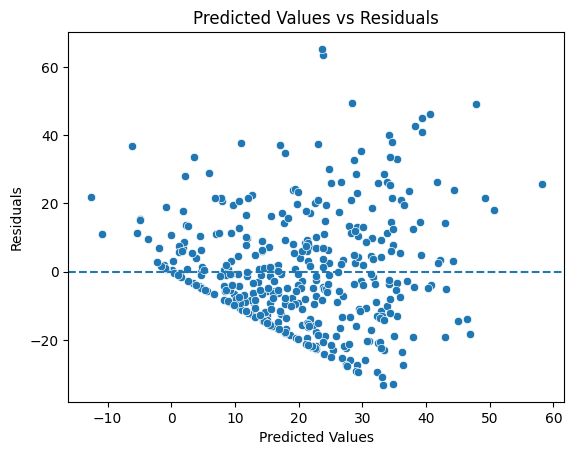

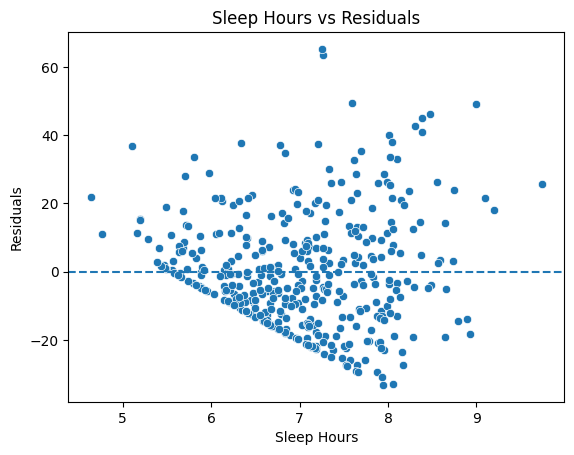

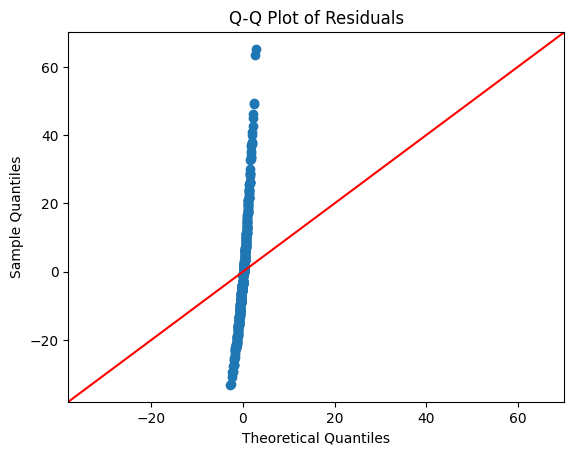

In [48]:
# Model Evaluation

residuals = model_5.resid
predictions = model_5.fittedvalues
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted Values vs Residuals")
plt.show()

sns.scatterplot(x=df["sleep_hours"], y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Sleep Hours")
plt.ylabel("Residuals")
plt.title("Sleep Hours vs Residuals")
plt.show()

sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

## Multiple Linear Regression

In [49]:
# Multiple Linear Regression
import statsmodels.api as sm
X = df[[

    "leisure_screen_hours",

    "work_screen_hours",

    "sleep_hours",

    "sleep_quality_1_5",

    "social_hours_per_week",

    "exercise_minutes_per_week"
]]

y = df["mental_wellness_index_0_100"]

X = sm.add_constant(X)

model_6 = sm.OLS(y, X).fit()

print(model_6.summary())

                                 OLS Regression Results                                
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.772
Model:                                     OLS   Adj. R-squared:                  0.769
Method:                          Least Squares   F-statistic:                     222.2
Date:                         Mon, 05 Oct 2026   Prob (F-statistic):          6.04e-123
Time:                                 03:01:03   Log-Likelihood:                -1476.9
No. Observations:                          400   AIC:                             2968.
Df Residuals:                              393   BIC:                             2996.
Df Model:                                    6                                         
Covariance Type:                     nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

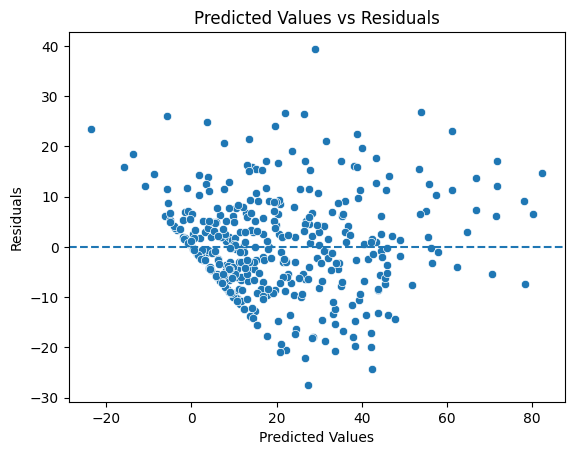

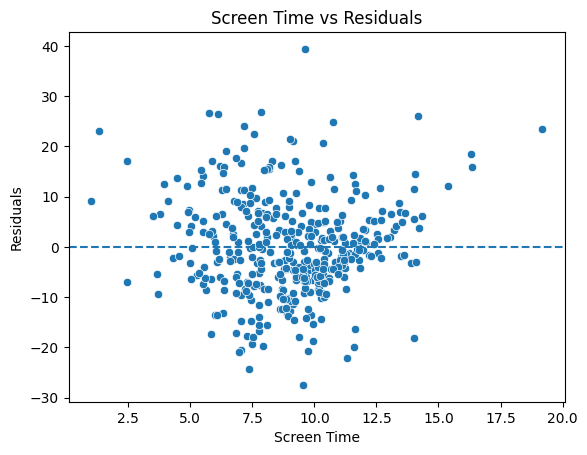

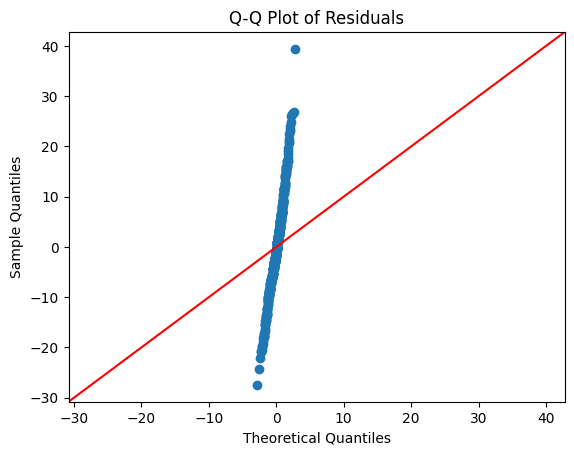

In [50]:
# Model Evaluation

residuals = model_6.resid
predictions = model_6.fittedvalues
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted Values vs Residuals")
plt.show()

sns.scatterplot(x=df['screen_time_hours'], y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Screen Time")
plt.ylabel("Residuals")
plt.title("Screen Time vs Residuals")
plt.show()

sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

OLS regression was explored as a method for quantifying linear associations between behavioral variables and mental wellness. However, several models exhibited heteroscedasticity, non-normal residual distributions, and floor/ceiling effects. These findings suggest that simple linear models may not fully capture the structure of the survey data.

# **Machine Learning**

In [86]:
# Importing machine learning modules
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

## **Test Model**

In [87]:
# Testing Model
X = df[[

    "leisure_screen_hours",

    "work_screen_hours",

    "sleep_quality_1_5",

    "social_hours_per_week",

    "exercise_minutes_per_week"

]]

y = df["mental_wellness_index_0_100"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=12)

test_model = RandomForestRegressor(random_state=12)

mae_score = -1*cross_val_score(test_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
rmse_model = -1*cross_val_score(test_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
r2_model = cross_val_score(test_model, X, y, cv=5, scoring='r2')

print("MAE ", mae_score.mean())
print("RMSE ", rmse_model.mean())
print("R2 ", r2_model.mean())


MAE  8.800833333333335
RMSE  11.663477478956478
R2  0.6899032542042866


In [88]:
# screen time + sleep_quality
# MAE  9.10265238888889
# RMSE  11.993381628813463
# R2  0.6791121187036706

# screen time + sleep_hours
# MAE  11.494766666666667
# RMSE  14.969646347937166
# R2  0.5053614785965614

# screen time + sleep_hours + sleep_quality
# MAE  9.065386666666665
# RMSE  11.908111655551522
# R2  0.675374692827913

In [89]:
# screen time + sleep_quality + exercise_minutes_per_week
# MAE  8.955643333333331
# RMSE  11.819841556233522
# R2  0.69461889228995

# screen time + sleep_quality + social_hours_per_week
# MAE  8.977753333333336
# RMSE  11.700299997031319
# R2  0.6776959021791689

# screen time + sleep_quality + social_hours_per_week + exercise_minutes_per_week
# MAE  8.800833333333335
# RMSE  11.663477478956478
# R2  0.6899032542042866

# Screen time = leisure screen time + work screen time

For optimal performance, the model needs to include screen time, sleep_quality, social_hours_per_week, and exercise_hours_per_week.

## Original Model

In [90]:
# Machine learning
X = df[[

    "leisure_screen_hours",

    "work_screen_hours",

    "sleep_quality_1_5",

    "social_hours_per_week",

    "exercise_minutes_per_week"

]]

y = df["mental_wellness_index_0_100"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=12)

ML_model = RandomForestRegressor(random_state=12)
ML_model.fit(X_train, y_train)
prediction = ML_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, prediction))
print("Root of Mean Squared Error:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 Score:", r2_score(y_test, prediction))


Mean Absolute Error: 7.656670000000002
Root of Mean Squared Error: 9.444828979393963
R2 Score: 0.7089060714886762


In [91]:
# Checking for overfitting/underfitting

# Training set
print("Training MAE:", mean_absolute_error(y_train, ML_model.predict(X_train)))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, ML_model.predict(X_train))))
print("Training R2:", ML_model.score(X_train, y_train))

# Testing set
print("Testing MAE:", mean_absolute_error(y_test, prediction))
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("Testing R2:", ML_model.score(X_test, y_test))

Training MAE: 3.2422033333333333
Training RMSE: 4.333646936472792
Training R2: 0.9581535253489794
Testing MAE: 7.656670000000002
Testing RMSE: 9.444828979393963
Testing R2: 0.7089060714886762


The gap between the training set and the testing set indicates potential overfitting in the current model.

## **Model Optimization**

### **Optimization for max_depth**

In [92]:
# Importing module for cross validation
from sklearn.model_selection import cross_val_score


# Defining functions for max depth optimization
def get_mae(max_depth, X_train, y_train):
    ML_model = RandomForestRegressor(max_depth=max_depth, random_state=12)
    mae = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return mae.mean()

def get_rmse(max_depth, X_train, y_train):
    ML_model = RandomForestRegressor(max_depth=max_depth, random_state=12)
    rmse = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return rmse.mean()

def get_r2(max_depth, X_train, y_train):
    ML_model = RandomForestRegressor(max_depth=max_depth, random_state=12)
    r2 = cross_val_score(ML_model, X_train, y_train, cv=5, scoring='r2')
    return r2.mean()

In [60]:
# Finding a test range
min_mae = float('inf')
min_rmse = float('inf')
max_r2 = float('-inf')

for max_depth in range(1,20):
    mae = get_mae(max_depth, X_train, y_train)
    if mae < min_mae:
        min_mae = mae
        result = max_depth
print(result)
print(min_mae)

for max_depth in range(1,20):
    rmse = get_rmse(max_depth, X_train, y_train)
    if rmse < min_rmse:
        min_rmse = rmse
        result = max_depth
print(result)
print(min_rmse)


for max_depth in range(1,20):
    r2 = get_r2(max_depth, X_train, y_train)
    if r2 > max_r2:
        max_r2 = r2
        result = max_depth
print(result)
print(max_r2)

11
8.773834098440156
5
11.589609977220382
5
0.6868662456329938


In [61]:
# Creating a data table for max_depth
max_depth_optimization = pd.DataFrame(index=range(1, 10), columns=['MAE', 'RMSE', 'R2'])

for max_depth in range(1, 10):
    result = get_mae(max_depth, X_train, y_train)
    max_depth_optimization.loc[max_depth, 'MAE'] = result


for max_depth in range(1, 10):
    result = get_rmse(max_depth, X_train, y_train)
    max_depth_optimization.loc[max_depth, 'RMSE'] = result


for max_depth in range(1, 10):
    result = get_r2(max_depth, X_train, y_train)
    max_depth_optimization.loc[max_depth, 'R2'] = result

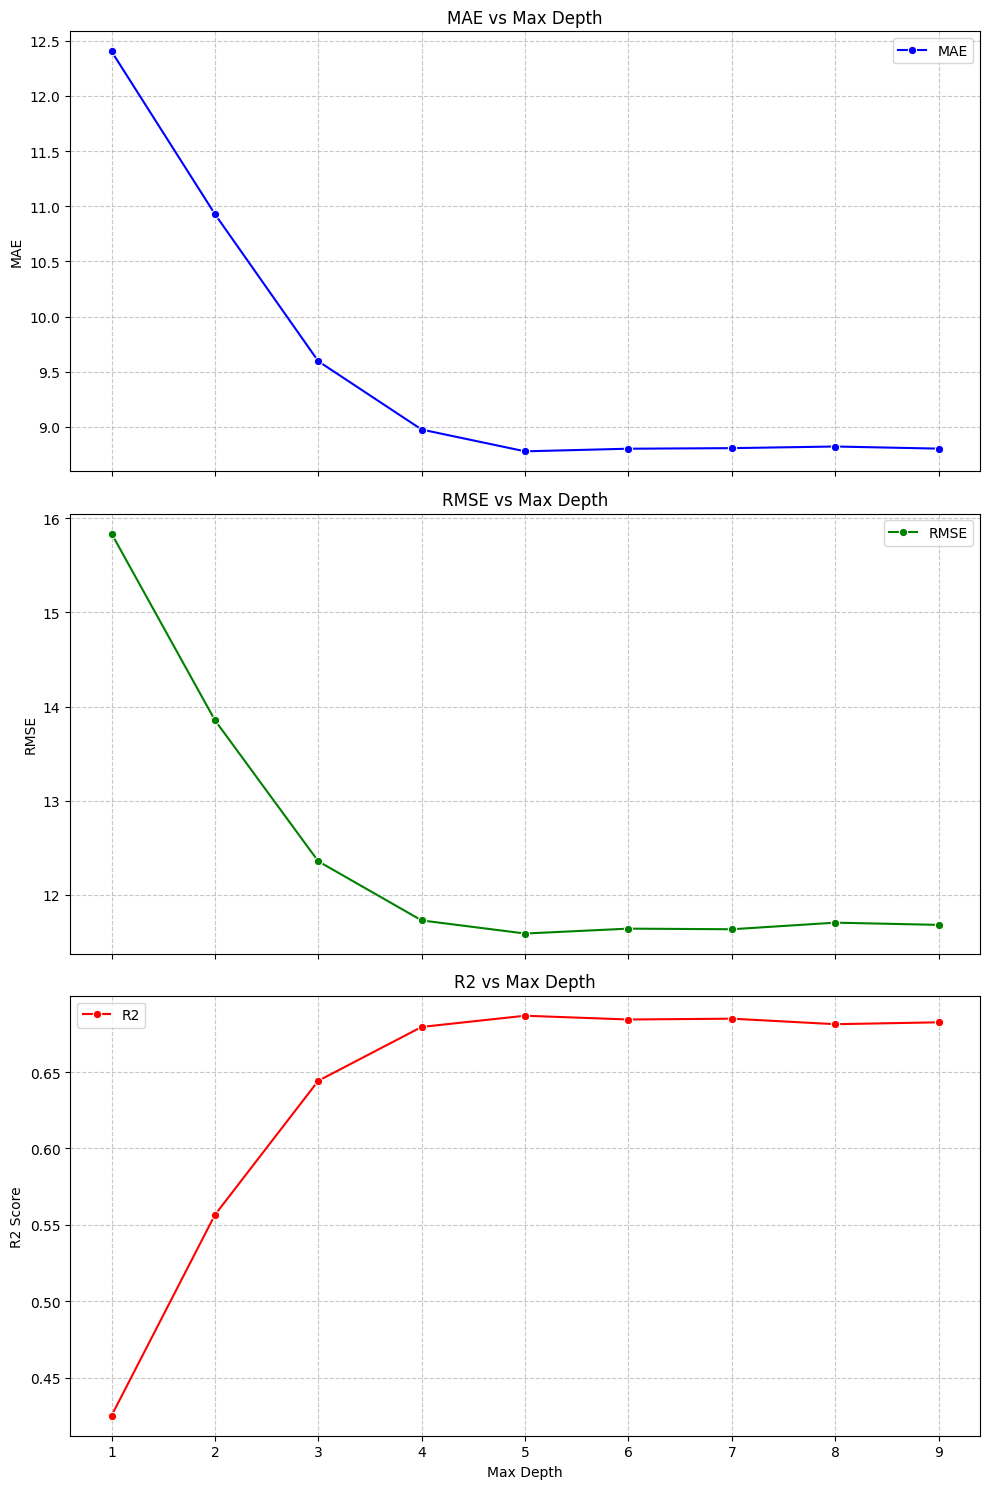

In [62]:
# Plotting the table
max_depth_optimization['Max Depth'] = max_depth_optimization.index

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

sns.lineplot(ax=axes[0], x=max_depth_optimization['Max Depth'], y=max_depth_optimization['MAE'], marker='o', label='MAE', color='blue')
axes[0].set_title('MAE vs Max Depth')
axes[0].set_ylabel('MAE')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(ax=axes[1], x=max_depth_optimization['Max Depth'], y=max_depth_optimization['RMSE'], marker='o', label='RMSE', color='green')
axes[1].set_title('RMSE vs Max Depth')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(ax=axes[2], x=max_depth_optimization['Max Depth'], y=max_depth_optimization['R2'], marker='o', label='R2', color='red')
axes[2].set_title('R2 vs Max Depth')
axes[2].set_xlabel('Max Depth')
axes[2].set_ylabel('R2 Score')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.xticks(range(1, 10))
plt.tight_layout()
plt.show()

The optimal max depth is 5

### **Optimization for min_samples_leaf**

In [63]:
# Defining functions for min_samples_leaf
def get_mae(min_samples_leaf, X_train, y_train):
    ML_model = RandomForestRegressor(min_samples_leaf=min_samples_leaf, random_state=12)
    mae = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return mae.mean()

def get_rmse(min_samples_leaf, X_train, y_train):
    ML_model = RandomForestRegressor(min_samples_leaf=min_samples_leaf, random_state=12)
    rmse = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return rmse.mean()

def get_r2(min_samples_leaf, X_train, y_train):
    ML_model = RandomForestRegressor(min_samples_leaf=min_samples_leaf, random_state=12)
    r2 = cross_val_score(ML_model, X_train, y_train, cv=5, scoring='r2')
    return r2.mean()

In [64]:
# Finding the optimal min_samples_leaf

min_mae = float('inf')
min_rmse = float('inf')
max_r2 = float('-inf')

for min_samples_leaf in range(1,20):
    mae = get_mae(min_samples_leaf, X_train, y_train)
    if mae < min_mae:
        min_mae = mae
        result = min_samples_leaf
print(result)
print(min_mae)


for min_samples_leaf in range(1,20):
    rmse = get_rmse(min_samples_leaf, X_train, y_train)
    if rmse < min_rmse:
        min_rmse = rmse
        result = min_samples_leaf
print(result)
print(min_rmse)


for min_samples_leaf in range(1,20):
    r2 = get_r2(min_samples_leaf, X_train, y_train)
    if r2 > max_r2:
        max_r2 = r2
        result = min_samples_leaf
print(result)
print(max_r2)

2
8.748605131803384
2
11.57036972627178
2
0.6879133550087742


In [65]:
# Creating a data table for min_samples_leaf
min_samples_leaf_optimization = pd.DataFrame(index=range(1,20), columns=['MAE', 'RMSE', 'R2'])


for min_samples_leaf in range(1,20):
    result = get_mae(min_samples_leaf, X_train, y_train)
    min_samples_leaf_optimization.loc[min_samples_leaf, 'MAE'] = result


for min_samples_leaf in range(1,20):
    result = get_rmse(min_samples_leaf, X_train, y_train)
    min_samples_leaf_optimization.loc[min_samples_leaf, 'RMSE'] = result


for min_samples_leaf in range(1,20):
    result = get_r2(min_samples_leaf, X_train, y_train)
    min_samples_leaf_optimization.loc[min_samples_leaf, 'R2'] = result


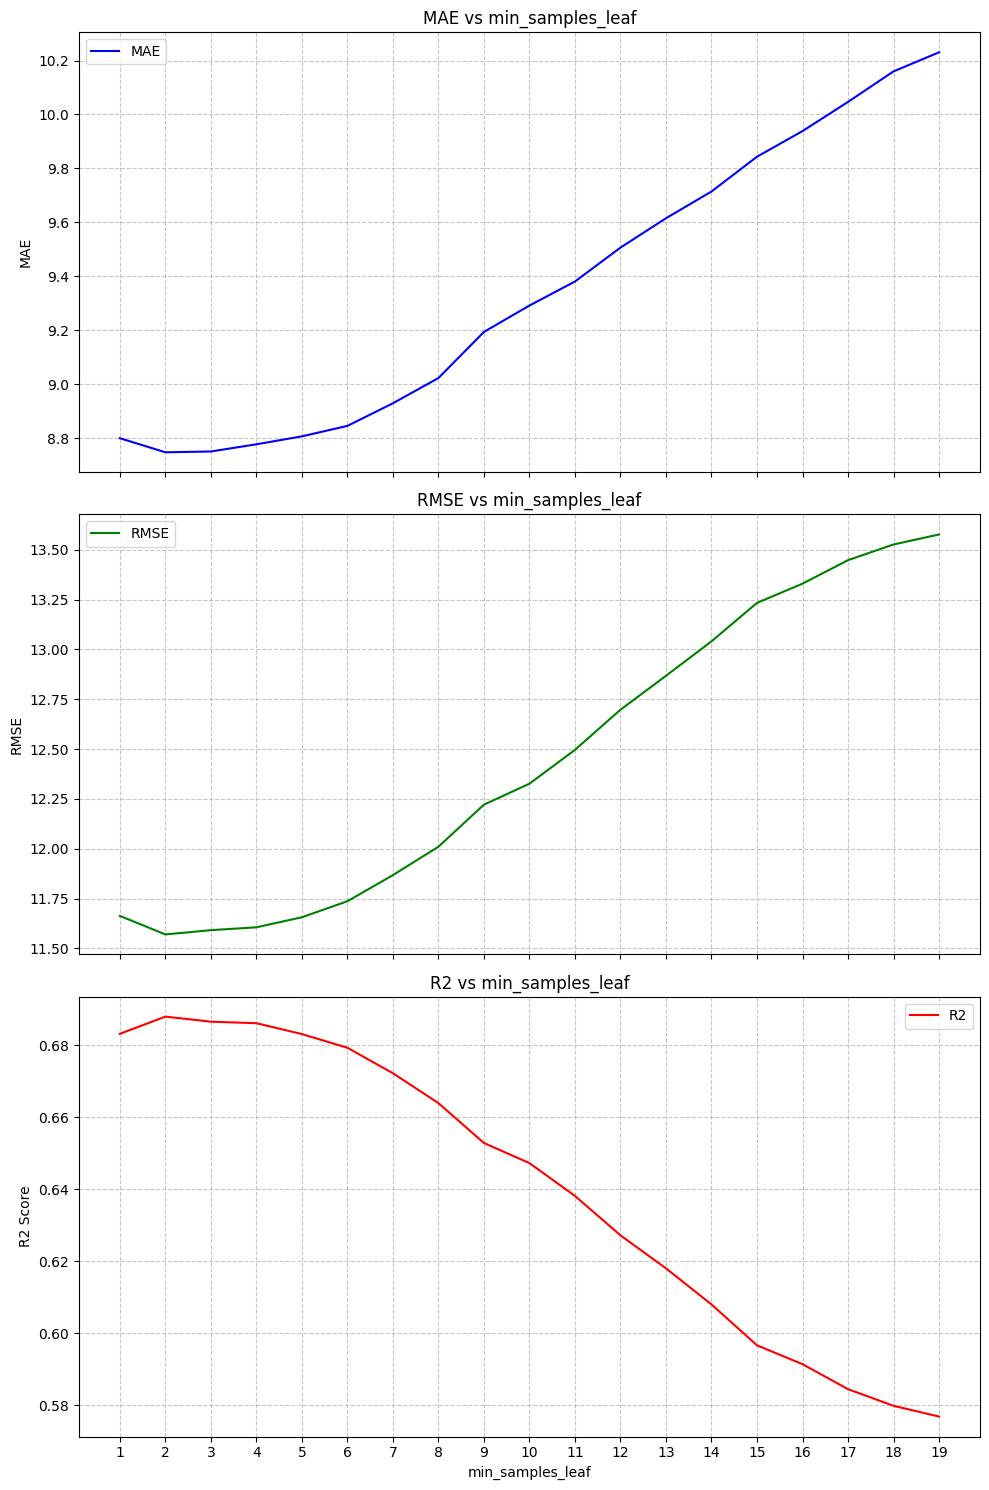

In [66]:
# Plotting the table
min_samples_leaf_optimization['min_samples_leaf'] = min_samples_leaf_optimization.index

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

sns.lineplot(ax=axes[0], x=min_samples_leaf_optimization["min_samples_leaf"], y=min_samples_leaf_optimization["MAE"], markers="o", label="MAE", color = "blue")
axes[0].set_title("MAE vs min_samples_leaf")
axes[0].set_ylabel("MAE")
axes[0].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[1], x=min_samples_leaf_optimization["min_samples_leaf"], y=min_samples_leaf_optimization["RMSE"], markers="o", label="RMSE", color = "green")
axes[1].set_title("RMSE vs min_samples_leaf")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[2], x=min_samples_leaf_optimization["min_samples_leaf"], y=min_samples_leaf_optimization["R2"], markers="o", label="R2", color = "red")
axes[2].set_title("R2 vs min_samples_leaf")
axes[2].set_xlabel("min_samples_leaf")
axes[2].set_ylabel("R2 Score")
axes[2].grid(True, linestyle="--", alpha=0.7)

plt.xticks(range(1,20))
plt.tight_layout()
plt.show()

The optimal min_samples_leaf is 2

### **Optimization for min_samples_split**

In [67]:
# Defining functions for min_samples_split
def get_mae(min_samples_split, X_train, y_train):
    ML_model = RandomForestRegressor(min_samples_split=min_samples_split, random_state=12)
    mae = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return mae.mean()

def get_rmse(min_samples_split, X_train, y_train):
    ML_model = RandomForestRegressor(min_samples_split=min_samples_split, random_state=12)
    rmse = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return rmse.mean()

def get_r2(min_samples_split, X_train, y_train):
    ML_model = RandomForestRegressor(min_samples_split=min_samples_split, random_state=12)
    r2 = cross_val_score(ML_model, X_train, y_train, cv=5, scoring='r2')
    return r2.mean()

In [68]:
# Finding the optimal min_samples_split

min_mae = float('inf')
min_rmse = float('inf')
max_r2 = float('-inf')

test_range = range(2,20)

for min_samples_split in test_range:
    mae = get_mae(min_samples_split, X_train, y_train)
    if mae < min_mae:
        min_mae = mae
        result = min_samples_split
print(result)
print(min_mae)


for min_samples_split in test_range:
    rmse = get_rmse(min_samples_split, X_train, y_train)
    if rmse < min_rmse:
        min_rmse = rmse
        result = min_samples_split
print(result)
print(min_rmse)


for min_samples_split in test_range:
    r2 = get_r2(min_samples_split, X_train, y_train)
    if r2 > max_r2:
        max_r2 = r2
        result = min_samples_split
print(result)
print(max_r2)

9
8.779403280683685
9
11.607798250635232
9
0.6854703355942459


In [69]:
# Creating a data table for min_samples_split
min_samples_split_optimization = pd.DataFrame(index=range(2,20), columns=['MAE', 'RMSE', 'R2'])


for min_samples_split in range(2,20):
    result = get_mae(min_samples_split, X_train, y_train)
    min_samples_split_optimization.loc[min_samples_split, 'MAE'] = result


for min_samples_split in range(2,20):
    result = get_rmse(min_samples_split, X_train, y_train)
    min_samples_split_optimization.loc[min_samples_split, 'RMSE'] = result


for min_samples_split in range(2,20):
    result = get_r2(min_samples_split, X_train, y_train)
    min_samples_split_optimization.loc[min_samples_split, 'R2'] = result

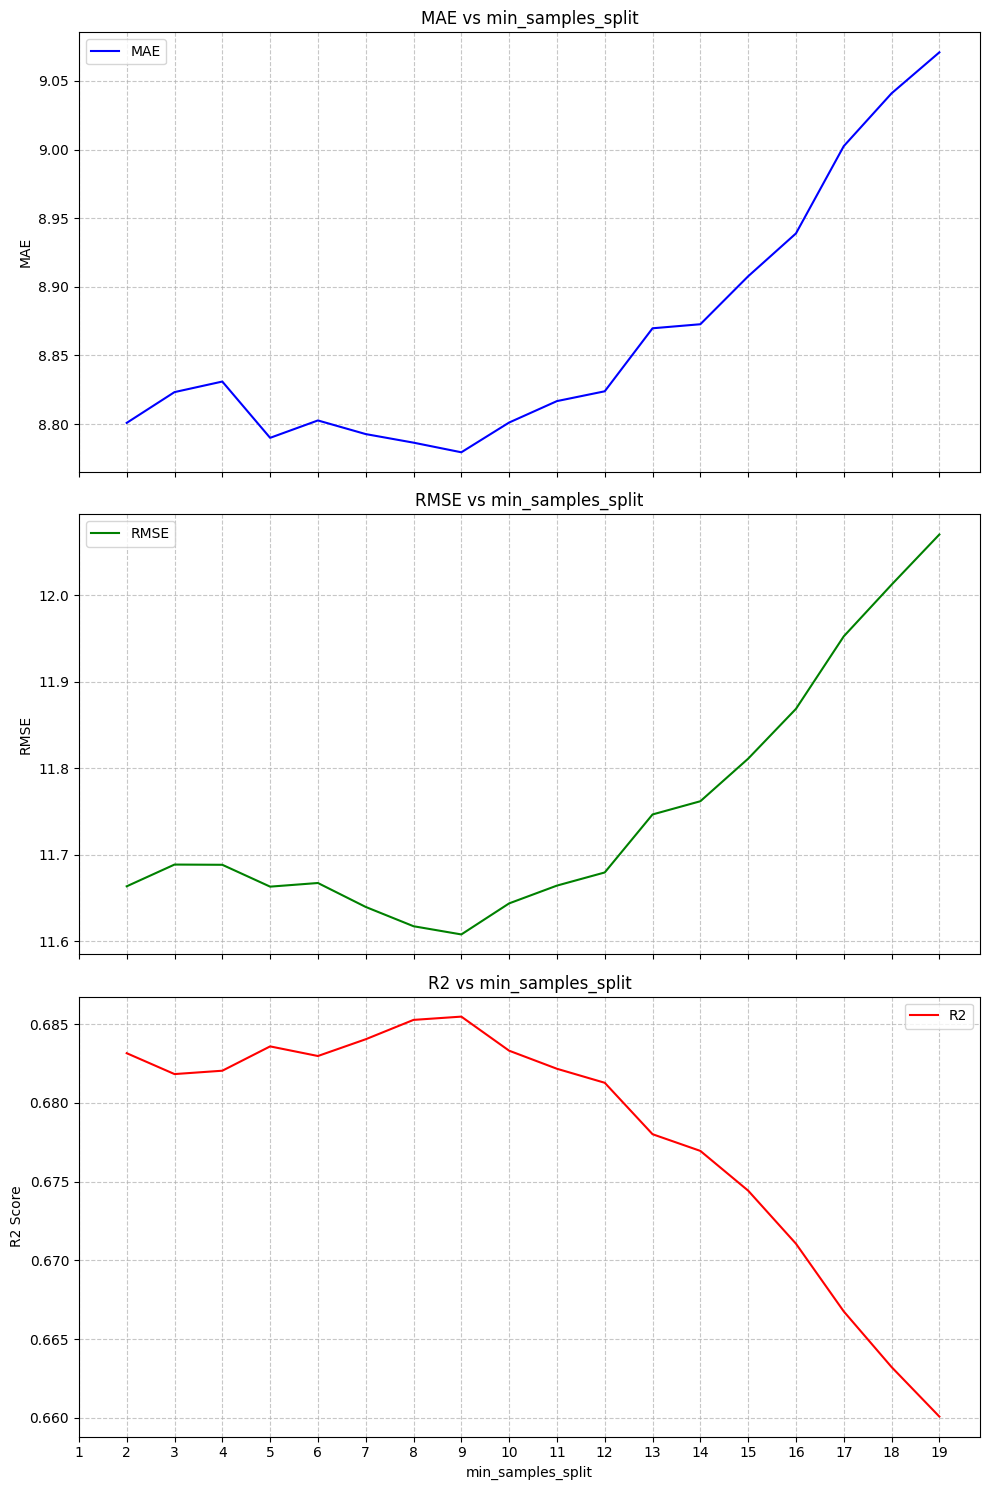

In [70]:
# Plotting the table
min_samples_split_optimization['min_samples_split'] = min_samples_split_optimization.index

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

sns.lineplot(ax=axes[0], x=min_samples_split_optimization["min_samples_split"], y=min_samples_split_optimization["MAE"], markers="o", label="MAE", color = "blue")
axes[0].set_title("MAE vs min_samples_split")
axes[0].set_ylabel("MAE")
axes[0].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[1], x=min_samples_split_optimization["min_samples_split"], y=min_samples_split_optimization["RMSE"], markers="o", label="RMSE", color = "green")
axes[1].set_title("RMSE vs min_samples_split")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[2], x=min_samples_split_optimization["min_samples_split"], y=min_samples_split_optimization["R2"], markers="o", label="R2", color = "red")
axes[2].set_title("R2 vs min_samples_split")
axes[2].set_xlabel("min_samples_split")
axes[2].set_ylabel("R2 Score")
axes[2].grid(True, linestyle="--", alpha=0.7)

plt.xticks(range(1,20))
plt.tight_layout()
plt.show()

The optimal min_samples_split is 9

### **Optimization for max_features**

In [71]:
# Defining functions for max_features
def get_mae(max_features, X_train, y_train):
    ML_model = RandomForestRegressor(max_features=max_features, random_state=12)
    mae = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return mae.mean()

def get_rmse(max_features, X_train, y_train):
    ML_model = RandomForestRegressor(max_features=max_features, random_state=12)
    rmse = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return rmse.mean()

def get_r2(max_features, X_train, y_train):
    ML_model = RandomForestRegressor(max_features=max_features, random_state=12)
    r2 = cross_val_score(ML_model, X_train, y_train, cv=5, scoring='r2')
    return r2.mean()

In [72]:
# Finding the optimal max_features

min_mae = float('inf')
min_rmse = float('inf')
max_r2 = float('-inf')

test_range = range(1, 6)

for max_features in test_range:
    mae = get_mae(max_features, X_train, y_train)
    if mae < min_mae:
        min_mae = mae
        result = max_features
print(result)
print(min_mae)


for max_features in test_range:
    rmse = get_rmse(max_features, X_train, y_train)
    if rmse < min_rmse:
        min_rmse = rmse
        result = max_features
print(result)
print(min_rmse)


for max_features in test_range:
    r2 = get_r2(max_features, X_train, y_train)
    if r2 > max_r2:
        max_r2 = r2
        result = max_features
print(result)
print(max_r2)

3
8.720923333333332
3
11.649595049987516
2
0.6847260814840676


In [73]:
# Creating a data table for max_features
max_features_optimization = pd.DataFrame(index=test_range, columns=['MAE', 'RMSE', 'R2'])


for max_features in test_range:
    result = get_mae(max_features, X_train, y_train)
    max_features_optimization.loc[max_features, 'MAE'] = result


for max_features in test_range:
    result = get_rmse(max_features, X_train, y_train)
    max_features_optimization.loc[max_features, 'RMSE'] = result


for max_features in test_range:
    result = get_r2(max_features, X_train, y_train)
    max_features_optimization.loc[max_features, 'R2'] = result

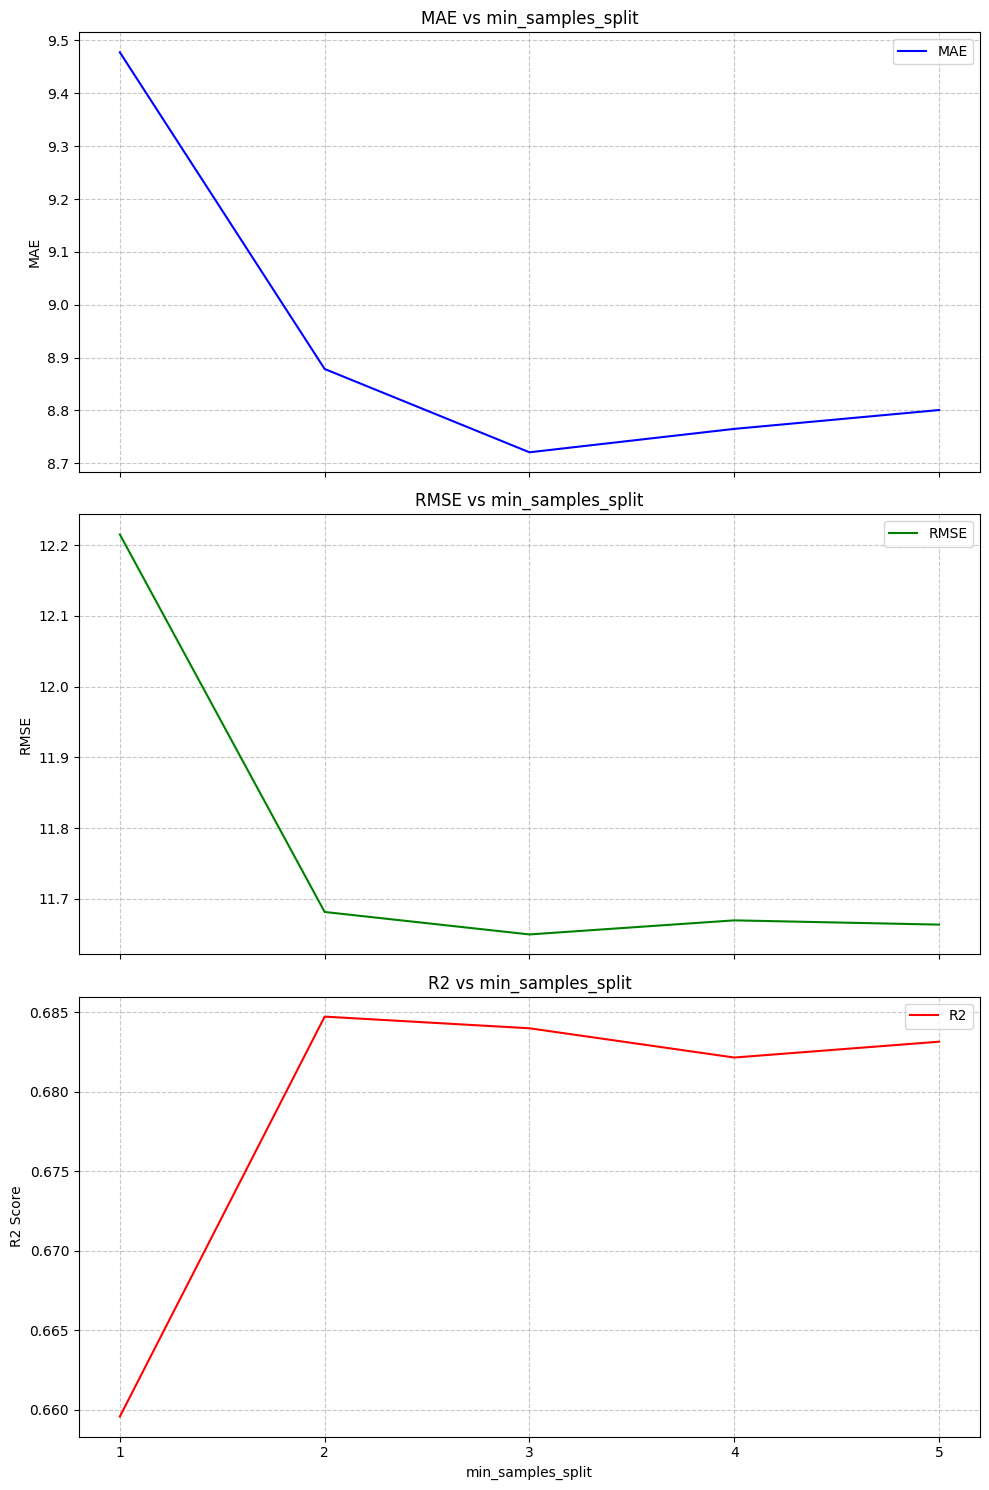

In [74]:
# Plotting the table
max_features_optimization['min_samples_split'] = max_features_optimization.index

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

sns.lineplot(ax=axes[0], x=max_features_optimization["min_samples_split"], y=max_features_optimization["MAE"], markers="o", label="MAE", color = "blue")
axes[0].set_title("MAE vs min_samples_split")
axes[0].set_ylabel("MAE")
axes[0].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[1], x=max_features_optimization["min_samples_split"], y=max_features_optimization["RMSE"], markers="o", label="RMSE", color = "green")
axes[1].set_title("RMSE vs min_samples_split")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[2], x=max_features_optimization["min_samples_split"], y=max_features_optimization["R2"], markers="o", label="R2", color = "red")
axes[2].set_title("R2 vs min_samples_split")
axes[2].set_xlabel("min_samples_split")
axes[2].set_ylabel("R2 Score")
axes[2].grid(True, linestyle="--", alpha=0.7)

plt.xticks(test_range)
plt.tight_layout()
plt.show()

The optimal max_features is 3

### **Optimization for n_estimators**

In [75]:
# Defining functions for n_estimators
def get_mae(n_estimators, X_train, y_train):
    ML_model = RandomForestRegressor(n_estimators=n_estimators, random_state=12)
    mae = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return mae.mean()

def get_rmse(n_estimators, X_train, y_train):
    ML_model = RandomForestRegressor(n_estimators=n_estimators, random_state=12)
    rmse = -1*cross_val_score(ML_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return rmse.mean()

def get_r2(n_estimators, X_train, y_train):
    ML_model = RandomForestRegressor(n_estimators=n_estimators, random_state=12)
    r2 = cross_val_score(ML_model, X_train, y_train, cv=5, scoring='r2')
    return r2.mean()

In [76]:
# Finding the optimal n_estimators

min_mae = float('inf')
min_rmse = float('inf')
max_r2 = float('-inf')

test_range = range(110, 180)

for n_estimators in test_range:
    mae = get_mae(n_estimators, X_train, y_train)
    if mae < min_mae:
        min_mae = mae
        result = n_estimators
print(result)
print(min_mae)


for n_estimators in test_range:
    rmse = get_rmse(n_estimators, X_train, y_train)
    if rmse < min_rmse:
        min_rmse = rmse
        result = n_estimators
print(result)
print(min_rmse)


for n_estimators in test_range:
    r2 = get_r2(n_estimators, X_train, y_train)
    if r2 > max_r2:
        max_r2 = r2
        result = n_estimators
print(result)
print(max_r2)

144
8.753449074074075
113
11.611403513134992
113
0.6863968046229512


In [77]:
# Creating a data table for n_estimators
n_estimators_optimization = pd.DataFrame(index=range(100,150), columns=['MAE', 'RMSE', 'R2'])


for n_estimators in range(100,150):
    result = get_mae(n_estimators, X_train, y_train)
    n_estimators_optimization.loc[n_estimators, 'MAE'] = result


for n_estimators in range(100,150):
    result = get_rmse(n_estimators, X_train, y_train)
    n_estimators_optimization.loc[n_estimators, 'RMSE'] = result


for n_estimators in range(100,150):
    result = get_r2(n_estimators, X_train, y_train)
    n_estimators_optimization.loc[n_estimators, 'R2'] = result

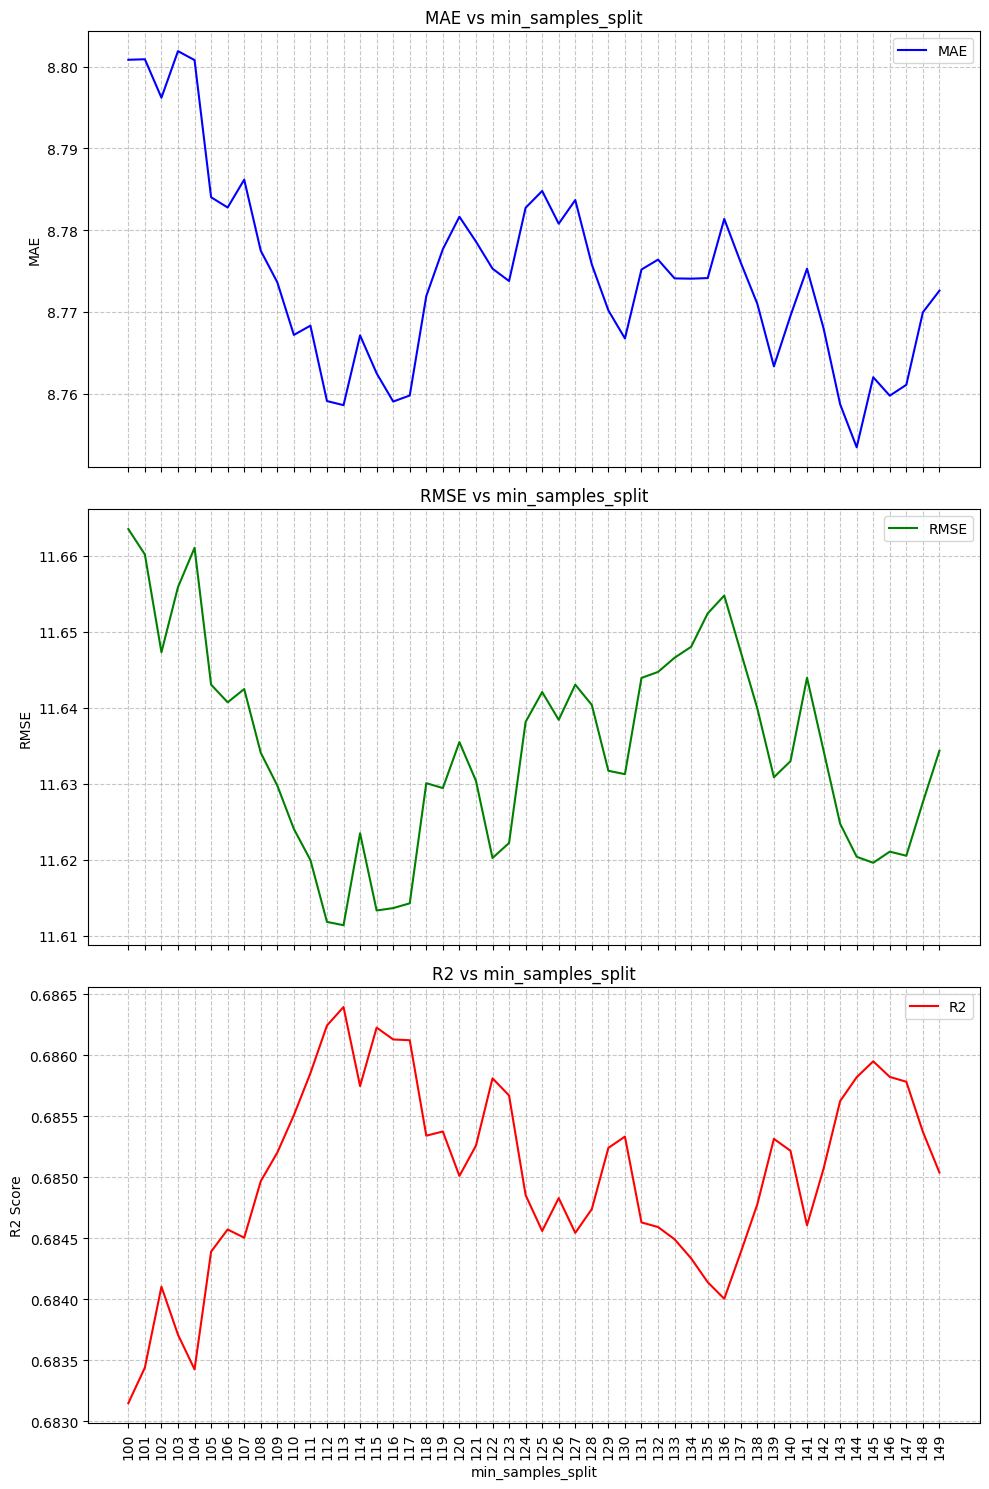

In [78]:
# Plotting the table
n_estimators_optimization['min_samples_split'] = n_estimators_optimization.index

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

sns.lineplot(ax=axes[0], x=n_estimators_optimization["min_samples_split"], y=n_estimators_optimization["MAE"], markers="o", label="MAE", color = "blue")
axes[0].set_title("MAE vs min_samples_split")
axes[0].set_ylabel("MAE")
axes[0].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[1], x=n_estimators_optimization["min_samples_split"], y=n_estimators_optimization["RMSE"], markers="o", label="RMSE", color = "green")
axes[1].set_title("RMSE vs min_samples_split")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, linestyle="--", alpha=0.7)

sns.lineplot(ax=axes[2], x=n_estimators_optimization["min_samples_split"], y=n_estimators_optimization["R2"], markers="o", label="R2", color = "red")
axes[2].set_title("R2 vs min_samples_split")
axes[2].set_xlabel("min_samples_split")
axes[2].set_ylabel("R2 Score")
axes[2].grid(True, linestyle="--", alpha=0.7)

plt.xticks(range(100,150), rotation=90)
plt.tight_layout()
plt.show()

The optimal n_estimators is 113

## **Final Model Examination**

In [79]:
X = df[[

    "leisure_screen_hours",

    "work_screen_hours",

    "sleep_quality_1_5",

    "social_hours_per_week",

    "exercise_minutes_per_week"
]]

y = df["mental_wellness_index_0_100"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=12)

final_model = RandomForestRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=9, max_features=3, n_estimators=113, random_state=12)
final_model.fit(X_train, y_train)
prediction = final_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, prediction))
print("Root of Mean Squared Error:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 Score:", r2_score(y_test, prediction))

Mean Absolute Error: 7.5122670477064775
Root of Mean Squared Error: 9.153354429008267
R2 Score: 0.7265955943029165


In [80]:
# Scores without tuning
# Mean Absolute Error: 7.656670000000002
# Root of Mean Squared Error: 9.444828979393963
# R2 Score: 0.7089060714886762

In [81]:
# Checking for overfitting/underfitting

# Training set
print("Training MAE:", mean_absolute_error(y_train, final_model.predict(X_train)))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, final_model.predict(X_train))))
print("Training R2:", final_model.score(X_train, y_train))

# Testing set
print("Testing MAE:", mean_absolute_error(y_test, prediction))
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("Testing R2:", final_model.score(X_test, y_test))

Training MAE: 6.668415442711986
Training RMSE: 8.562568358267173
Training R2: 0.8366346575524101
Testing MAE: 7.5122670477064775
Testing RMSE: 9.153354429008267
Testing R2: 0.7265955943029165


After hyperparameter tuning, the Random Forest model achieved an R² of 0.726 on the testing set, compared with 0.836 on the training set. The relatively small difference between training and testing performance suggests that tuning reduced the model’s previous overfitting while maintaining strong predictive performance.

## **Linear Regression Model**

In [82]:
# Creating a linear regression model
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_prediction = linear_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, linear_prediction))
print("MSE:", mean_squared_error(y_test, linear_prediction))
print("R2:", r2_score(y_test, linear_prediction))

MAE: 6.8026699334213525
MSE: 75.82104895763723
R2: 0.7525800362972752


## **Model Comparison**

In [84]:
# Linear Regression
mae_score = -1*cross_val_score(linear_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
rmse_model = -1*cross_val_score(linear_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
r2_model = cross_val_score(linear_model, X, y, cv=5, scoring='r2')

print("MAE ", mae_score.mean())
print("RMSE ", rmse_model.mean())
print("R2 ", r2_model.mean())

MAE  8.01517004004275
RMSE  10.297105413473094
R2  0.7447585239358887


In [85]:
# Random Forrest Regression
mae_score = -1*cross_val_score(final_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
rmse_model = -1*cross_val_score(final_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
r2_model = cross_val_score(final_model, X, y, cv=5, scoring='r2')

print("MAE ", mae_score.mean())
print("RMSE ", rmse_model.mean())
print("R2 ", r2_model.mean())

MAE  8.939359041212537
RMSE  11.694533301389097
R2  0.6979023001194902


Even aftering tuning, the linear regression model still performs significantly better than random forreest regressor

# **Discussion**

The findings of this study show that the relationship between technology use and mental well-being is far more complex than can be explained by screen time alone. In general, greater screen time does seem to correspond with lower mental-wellness scores yet its relationships with sleep duration and sleep quality, on the other hand, were considerably weaker. Furthermore, the type of screen use is also worth noting, with leisure screen time showing a stronger association with mental wellness than work screen time. When multiple technological and lifestyle variables were combined, mental-wellness scores could be predicted to a moderate extent. However, the limitations in both the data and the modeling approaches still remained.

Initially, by plotting the two variables on a single scattered plot, it seems that there does exist a substantial correlation between screen time and mental wellness. This is further supported by the heat map that reveals a negative correlation of 0.64. Nonetheless, when fitting them into a linear regression model, the model only explained around 40% of the variance in mental-wellness scores. This indicates that though the association is substantial, a large proportion of variation remains unexplained by screen time alone. Moreover, when examining the statistical validity of this linear model, diagnostics revealed that the model suffered heteroscedasticity and floor/ceiling effects. Therefore, though the model captured some linearity within the data, the model does not fully satisfy the assumptions of ordinary linear regression. Hence, the model and especially its statistical inference should be interpreted with care.


Although the relationship between screen time and mental wellness was quite significant, the corresponding relationship between screen time and sleep was considerably weaker. When examining the potential correlation between screen time and sleep, the plots show that there do not exist any significant correlation for neither sleep duration nor sleep quality. Likewise, the heap map also points to the presence of only a slightly negative association between screen time and the above two variables. Moreover, after performing statistical analysis for both variables, the result still remained essentially the same as before. For sleep hours, the linear model only explains 11% of the variance. In the case of sleep quality, this drops even further to less than 8%. Thus, it shows that there does not seem to exist a statistically significant pattern between screen time and sleep.


Next, the relatively weak relationship between overall screen time and sleep also raises the question of whether the amount of screen use alone adequately represents the way technology may relate to mental wellness. This consideration becomes particularly relevant when distinguishing between work-related and leisure-related screen use. In fact, one of the most intriguing findings in this research derive from the correlation difference between these two kinds of screen usage. As demonstrated by the plots, it does appear that leisure screen time comprises of a slightly stronger connection with mental wellness compared to work screen time. Thus, this finding differs from the expectation that work-related screen time might have a stronger association with mental wellness. However, one important thing to note in this case is the distribution of this particular dataset. Though it is ideally centered and nearly symmetric for the distribution of leisure screen time, the distribution for work screen time is considerably skewed with the majority of the participants spending less than two hours of their screen time in actual work. Therefore, the observed difference in correlation may stem from the highly skewed distribution of work-related screen time.


Taken together, this findings leads to the examination of whether multiple technological and lifestyle variables could collectively improve the prediction of mental wellness. In order to determine the extent to which mental wellness can be predicted from these predictors, two predictive models were employed, the linear regression model and the random forrest model. During statistical analysis, numerous indicators were chosen to evaluate the predictability of mental wellness. These included both types of screen usage along with sleep duration, sleep quality, social hours, and exercise hours. These variables were selected according to the patterns identified during exploratory data analysis (EDA). The analysis began with the development of a multiple linear regression model incorporating the selected predictors. Looking at the model’s statistical measures, it seems that this particular model performed significantly better than previous single-variable models and explains over 76 percents of the variance. Nonetheless, a deeper diagnostic analysis revealed multiple violations to some of the underlying assumptions of an ordinary least squares regression such as heteroscedasticity and non-normality of the residuals. Hence, although the statistical analysis revealed meaningful associations between technology use, lifestyle variables, and mental wellness, the multiple linear regression model was nevertheless unable to fully capture the overall structure of the dataset. This suggests that mental wellness in this dataset is influenced by a more complex and potentially nonlinear combination of factors than could be adequately represented by a simple linear model. Consequently, a machine learning model was developed to determine whether a nonlinear approach could improve the overall predictive performance in comparison to a linear model.


In this case, a random forest model was employed in attempt to capture the potential nonlinear relationship within this particular dataset. The process began with cross-validation of numerous combinations of predictor variables to identify an appropriate feature set for this model. Afterward, it is decided that the optimal combination would include the two types of screen time along with sleep quality, social hours, and exercise hours. Next, an original random forest model is generated to obtain the initial performance measurements. The baseline model achieved a mean absolute error (MAE) of around 7.66 and an R2 value of 0.71. However, comparing the training and testing scores revealed a significant gap in model performance. Such difference indicates the existence of potential overfitting in the initial model. In order to address this issue, a series of optimizations were performed on all the critical parameters of a random forest model. Following the tuning, an evaluation of the final model then revealed a reduced gap between training and testing performance, suggesting that overfitting had been considerably mitigated. Moreover, the tuning also produced a slight improvement in the model’s overall predictive performance; however, the final tuned model still performed below the multiple linear regression model across numerous evaluation metrics. In summary, these findings suggest that increasing model complexity did not substantially improve prediction for this specific dataset and that the available variables may not fully capture the factors influencing mental well-being.

# **Limitation**

Several limitations of the dataset and methodology should be considered when interpreting the findings of this study. First, it must be noted that this particular dataset consists of only 400 responses. The relatively limited amount of collected data, combined with the unknown sampling procedure, makes it difficult to generalize the findings unto a broader population. Moreover, the dataset also only provides limited information regarding its authorship and the population from which the participants were sampled. Then, variables such as sleep quality, stress level, and productivity score are also all based upon subjective self-reports rather than objective measurements. Taken together, these limitations make it difficult to assess the overall reliability and representativeness of this specific dataset. Consequently, the patterns identified in the analysis should therefore be interpreted with caution. As discussed previously, several variables in this dataset exhibited skewed distributions. This was particularly the case with both work screen time as well as stress level. Hence, these distributions may directly alter the interpretation of relationships involving these variables. Moving forward, another important limitation concerns the distinction between correlation and causation. The findings in this study identified potential associations between two or more variables. However, these relationships do not necessarily establish causation. Technology use may have an association with mental wellness yet it does not follow that the use of technology will directly impact one’s mental state. Lastly, though the dataset includes over ten different variables, the findings suggest that there still are factors affecting mental wellness that may be absent. This is reflected from the overall performance of the two models deployed in this research. Potential missing predictors may include the difference in the specific types of technology, job compensation, and physical health. All these are possible indicators that might need to be considered in future research.

# **Conclusion**

The purpose of this research is to identify potential patterns between variables, especially among technology usage, life-style habits, and mental-wellness indicators. Overall, the findings show that while there is a stistcically significant correlation between screen usage and mental wellness, screen time by itself is insufficient to predict mental wellness, explaining only around 40% of the variance in mental-wellness scores. When examining the relationships between screen usage and sleep, the results suggest a statistically significant yet relatively weak association. Next, the analysis on the two types of screen usage also revealed a quite counterintuitive result. Rather than showing a stronger correlation with work-related screen time, mental wellness instead shows a stronger association with leisure-related screen use. Finally, the results also indicate that though both models can predict mental wellness to a moderate extent, the multi-linear regression model demonstrated a better predictive performance yet was nevertheless unable to fully explain the observed variation in mental-wellness scores. As for the random forest model, it performed noticeably worse than the linear model even after tuning. This indicates that increase in model complexity in this case did not correspond to any substantial improvement in model performance and that the variables available in this dataset may not fully capture the factors associated with mental wellness. Collectively, the findings suggest that mental wellness cannot be adequately represented by any single variable alone and that numerous technological, behavioral, and lifestyle factors all contribute to the observed variation in mental-wellness scores. Furthermore, the unexplained variation suggests that additional factors not present in the dataset may also be relevant to the study, ultimately providing potential directions for future research in this field.

# **Reference**

Kumaresan, A. (2025). Screen time vs mental wellness survey - 2025 [Data set]. Kaggle.
https://www.kaggle.com/datasets/adharshinikumar/screentime-vs-mentalwellness-survey-2025